# API: Application programming interface
An API is a set of rules and tools that allows different software applications to communicate with each other.

So, considering python as one sort of the software, allows it to talk to any other software and extract the sort of data.

Many companies obtaining business of model of Data As Services sells the API as thier key product. 


# A. Obtaining Share Price: A popular Yahoo Finance API

**Step 1: Import yahoo finance** 

!pip install yfinance

if not installed, Please install using pip

MacBook will execute the following pip command

$ pip install yfinance



In [1]:
'''Import the Yahooo finance library and pandas'''

import yfinance as yf
import pandas as pd



**Step 2: TICKER**

Every Stocks listed in NYSE and NASDAQ has its own ticker. 

we wee need to both identify stocks ticker and than fetch it into the yf ticker object

In [2]:


# Define ticker symbol for Google (Alphabet)
ticker = "GOOGL"

# Create a Ticker object
goog = yf.Ticker(ticker)

**Step 3: extracting data**

using history function of the yahoo finance, we are ready for extracting the data. 

Two Arguments are necessart

1. Range of Date

2. interval at which we need a data. Our case is daily.

In [3]:
'''Date:  from 2024-01-01 to 2024-11-01'''
'''Interval: daily data'''
data = goog.history(start="2024-01-01", end="2024-11-01", interval="1d")



In [4]:
# Print the first few rows
print(data.head())



                                 Open        High         Low       Close  \
Date                                                                        
2024-01-02 00:00:00-05:00  137.244038  138.135548  135.193542  136.867615   
2024-01-03 00:00:00-05:00  135.956293  138.313864  135.787897  137.610550   
2024-01-04 00:00:00-05:00  137.115249  137.848280  135.064769  135.104385   
2024-01-05 00:00:00-05:00  135.460982  135.867121  133.876057  134.450592   
2024-01-08 00:00:00-05:00  135.005329  137.699692  134.975613  137.531296   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-01-02 00:00:00-05:00  23711200        0.0           0.0  
2024-01-03 00:00:00-05:00  24212100        0.0           0.0  
2024-01-04 00:00:00-05:00  27137700        0.0           0.0  
2024-01-05 00:00:00-05:00  22513900        0.0           0.0  
2024-01-08 00:00:00-05:00  21404000        0.0           0.0  


** Step 4: Kind of Price**
The stock price can be of different level. Like, opening price is price which appear at beggining trading on a particular daya

closing price is last recorded share price on a particular day.

Depending upon the analytics, we obatain either open or closing price.

In [5]:
# Extract only the closing price column
close_prices = data["Close"]

# If you want, convert to a DataFrame with date as a column
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)

print(df_close.head())

                       Date       Close
0 2024-01-02 00:00:00-05:00  136.867615
1 2024-01-03 00:00:00-05:00  137.610550
2 2024-01-04 00:00:00-05:00  135.104385
3 2024-01-05 00:00:00-05:00  134.450592
4 2024-01-08 00:00:00-05:00  137.531296


In [6]:
df_close.to_csv("google_close_prices.csv", index=False)

In [7]:
'''Load google close price'''

df_google = pd.read_csv("google_close_prices.csv")
df_google.head()

,Date,Close
0,2024-01-02 00:00:00-05:00,136.867615
1,2024-01-03 00:00:00-05:00,137.610550
2,2024-01-04 00:00:00-05:00,135.104385
3,2024-01-05 00:00:00-05:00,134.450592
4,2024-01-08 00:00:00-05:00,137.531296


/var/folders/qr/qqkx12110914k3tn4fmdfr480000gn/T/ipykernel_74193/3951954986.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_google['Date'] = pd.to_datetime(df_google['Date'])


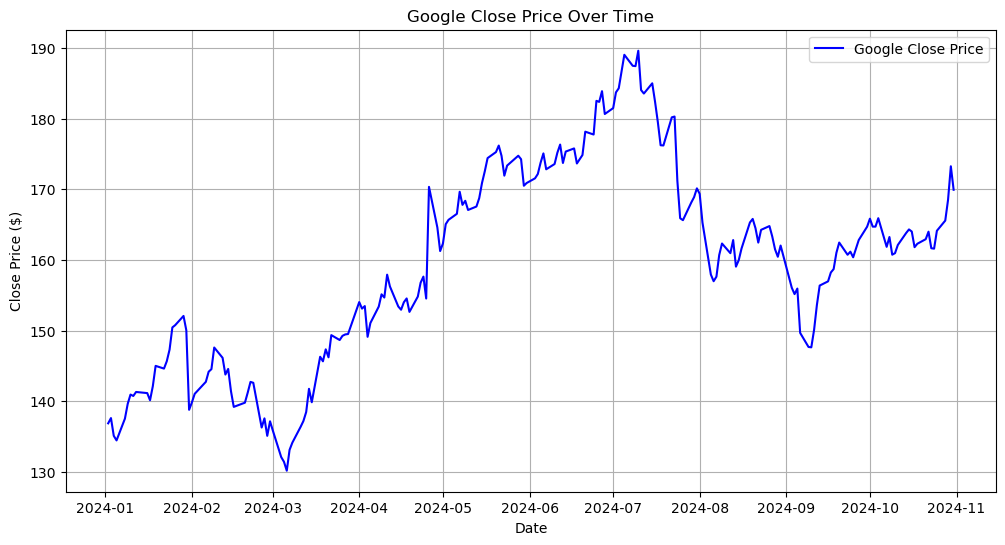

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
# Convert 'Date' column to datetime
df_google['Date'] = pd.to_datetime(df_google['Date'])

# Set 'Date' as the index (optional but makes plotting easier)
df_google.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_google.index, df_google['Close'], color='blue', label='Google Close Price')
plt.title('Google Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

# Obtaining price on mutliple stocks

In [9]:
import yfinance as yf
import pandas as pd

# List of ticker symbols
tickers = ["GOOGL", "AAPL", "MSFT"]  # Google, Apple, Microsoft

# Download historical daily data for all tickers
# Specify period (e.g., 2024-01-01 to 2024-11-01)
data = yf.download(tickers, start="2024-01-01", end="2024-11-01", interval="1d")

# Print first few rows
print(data.head())



[*********************100%***********************]  3 of 3 completed

Price            Close                                High              \
Ticker            AAPL       GOOGL        MSFT        AAPL       GOOGL   
Date                                                                     
2024-01-02  183.404007  136.867615  363.117981  186.170285  138.135548   
2024-01-03  182.030746  137.610550  362.853546  183.641118  138.313864   
2024-01-04  179.718948  135.104385  360.249146  180.884728  137.848280   
2024-01-05  178.997742  134.450592  360.063110  180.558713  135.867121   
2024-01-08  183.324966  137.531296  366.858063  183.364493  137.699692   

Price                          Low                                Open  \
Ticker            MSFT        AAPL       GOOGL        MSFT        AAPL   
Date                                                                     
2024-01-02  368.042841  181.675085  135.193542  359.103674  184.895814   
2024-01-03  365.457949  181.220616  135.787897  360.807236  182.001109   
2024-01-04  365.301292  178.701356  1

In [10]:
# Extract closing prices only
close_prices = data["Close"].copy()

# Remove top-level name if present
close_prices.columns.name = None

print(close_prices.head())


                  AAPL       GOOGL        MSFT
Date                                          
2024-01-02  183.404007  136.867615  363.117981
2024-01-03  182.030746  137.610550  362.853546
2024-01-04  179.718948  135.104385  360.249146
2024-01-05  178.997742  134.450592  360.063110
2024-01-08  183.324966  137.531296  366.858063


In [11]:
close_prices.to_csv("multiple_stocks_timesries.csv", index=True)

# Visulizing 

In [12]:
df_multiple = pd.read_csv("multiple_stocks_timesries.csv")
df_multiple.head()

,Date,AAPL,GOOGL,MSFT
0,2024-01-02,183.404007,136.867615,363.117981
1,2024-01-03,182.030746,137.610550,362.853546
2,2024-01-04,179.718948,135.104385,360.249146
3,2024-01-05,178.997742,134.450592,360.063110
4,2024-01-08,183.324966,137.531296,366.858063


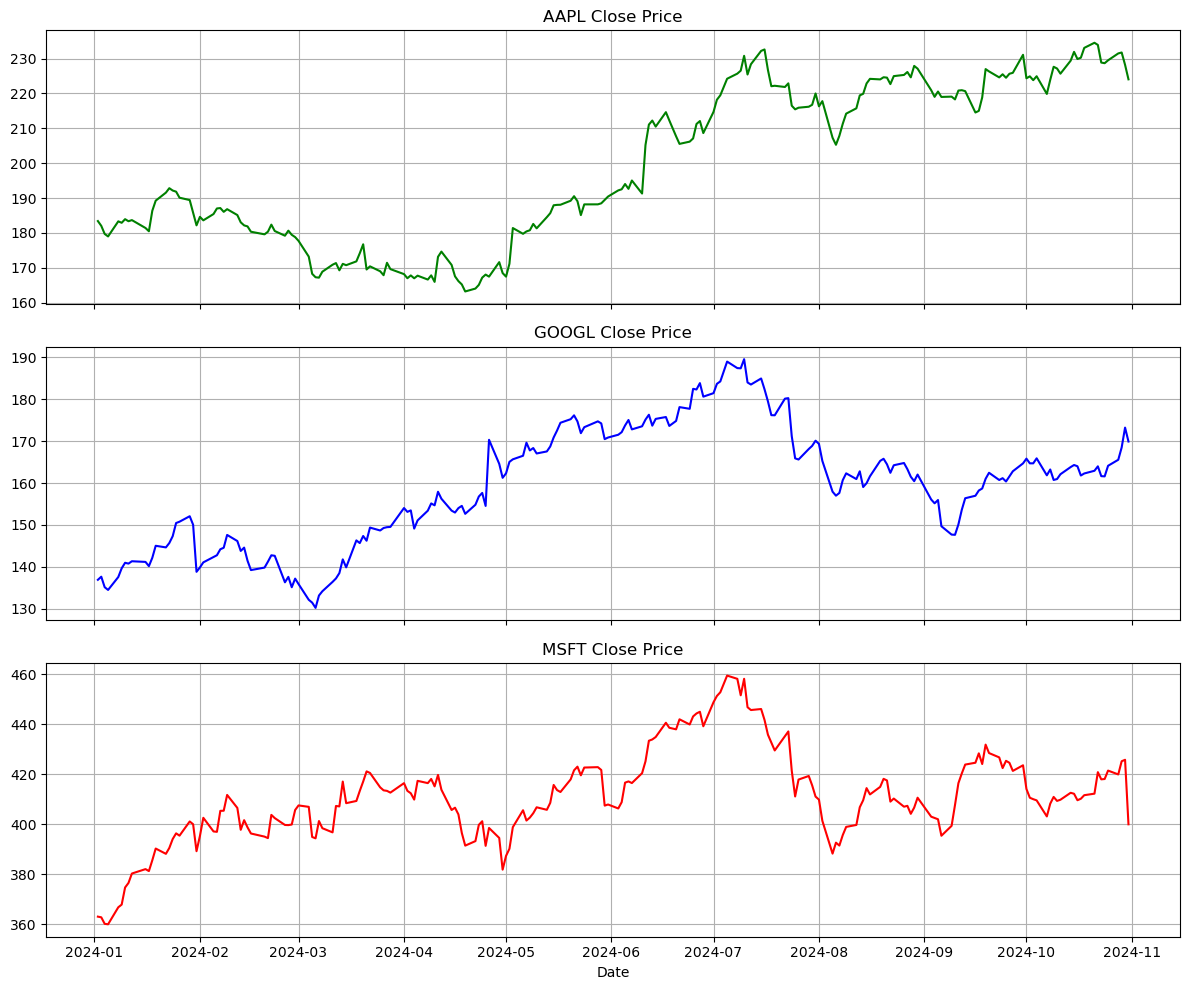

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


# Convert 'Date' column to datetime
df_multiple['Date'] = pd.to_datetime(df_multiple['Date'])

# Create subplots: 3 rows, 1 column, shared x-axis
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12,10), sharex=True)

# Plot each stock in its own subplot
axes[0].plot(df_multiple['Date'], df_multiple['AAPL'], color='green')
axes[0].set_title('AAPL Close Price')
axes[0].grid(True)

axes[1].plot(df_multiple['Date'], df_multiple['GOOGL'], color='blue')
axes[1].set_title('GOOGL Close Price')
axes[1].grid(True)

axes[2].plot(df_multiple['Date'], df_multiple['MSFT'], color='red')
axes[2].set_title('MSFT Close Price')
axes[2].grid(True)
axes[2].set_xlabel('Date')

# Adjust spacing
plt.tight_layout()
plt.show()


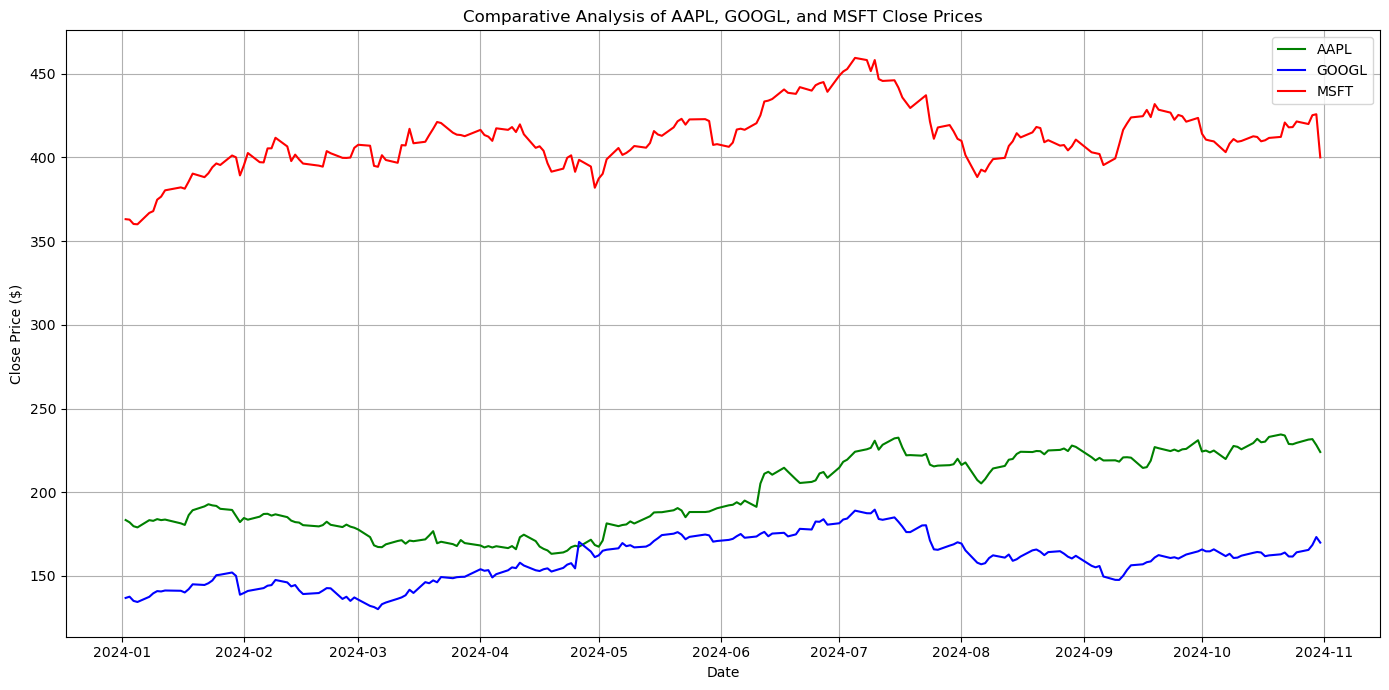

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_multiple = pd.read_csv("multiple_stocks_timesries.csv")

# Convert 'Date' column to datetime
df_multiple['Date'] = pd.to_datetime(df_multiple['Date'])

# Plot all three stocks in one figure
plt.figure(figsize=(14,7))
plt.plot(df_multiple['Date'], df_multiple['AAPL'], label='AAPL', color='green')
plt.plot(df_multiple['Date'], df_multiple['GOOGL'], label='GOOGL', color='blue')
plt.plot(df_multiple['Date'], df_multiple['MSFT'], label='MSFT', color='red')

# Titles and labels
plt.title('Comparative Analysis of AAPL, GOOGL, and MSFT Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# Panel Data Analytics

In [15]:
# Optional: convert to long format (Date, Ticker, Close)
df_close_long = close_prices.reset_index().melt(id_vars="Date", var_name="Ticker", value_name="Close")
print(df_close_long.head())

        Date Ticker       Close
0 2024-01-02   AAPL  183.404007
1 2024-01-03   AAPL  182.030746
2 2024-01-04   AAPL  179.718948
3 2024-01-05   AAPL  178.997742
4 2024-01-08   AAPL  183.324966


In [16]:
df_close_long.to_csv("multiple_stocks_prices_panel.csv", index=False)

# B. News API:

A powerful API to collect the news headline

In [17]:
import requests
from datetime import datetime

# Your NewsAPI key (register free at https://newsapi.org/)
api_key = ""

'''PUT YOUR NEWSAPI KEY HERE'''

'PUT YOUR NEWSAPI KEY HERE'

# KEYWORDS
'''q=apple. however, you can put any other keyword to search for news articles.'''


In [18]:
# Corrected URL
url = (
    f"https://newsapi.org/v2/everything?"
    f"q=apple&from=2025-11-21&to=2025-11-21&sortBy=popularity&apiKey={api_key}"
)


response = requests.get(url)
data = response.json()

articles = data.get("articles", [])
for i, article in enumerate(articles[:5], start=1):
    print(f"{i}. {article['title']} ({article['source']['name']})")


In [19]:
# Extract articles
articles = data.get("articles", [])

# Create DataFrame
df_articles = pd.DataFrame([{
    "Title": article['title'],
    "Source": article['source']['name'],
    "Description": article['description'],
    "URL": article['url'],
    "PublishedAt": datetime.strptime(article['publishedAt'], "%Y-%m-%dT%H:%M:%SZ")
} for article in articles])

# Show first 5 articles
pd.set_option("display.max_colwidth", None)  # show full text
print(df_articles.head())

Empty DataFrame
Columns: []
Index: []


In [20]:
df_articles.head(2)

""


In [21]:
df_articles.to_csv("apple_news_nov21_2025.csv", index=False)

# FULL High-end code: Trump

In [22]:
import requests
import csv
import time

# -----------------------------
# Configuration
# -----------------------------
API_KEY = ""  # Replace with your NewsAPI key
QUERY = "trump"
FROM_DATE = "2025-11-21"  # start date
TO_DATE = "2025-11-22"    # end date
LANGUAGE = "en"
PAGE_SIZE = 100            # max per request
CSV_FILE = "trump_articles.csv"

# -----------------------------
# Fetch articles function
# -----------------------------
def fetch_articles(page=1):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": QUERY,
        "from": FROM_DATE,
        "to": TO_DATE,
        "language": LANGUAGE,
        "sortBy": "publishedAt",
        "pageSize": PAGE_SIZE,
        "page": page,
        "apiKey": API_KEY
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        print(f"Error fetching page {page}: {response.status_code} - {response.text}")
        return None
    return response.json()

# -----------------------------
# Save articles to CSV
# -----------------------------
def save_to_csv(articles, filename):
    keys = ["source", "author", "title", "description", "url", "publishedAt", "content"]
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        for article in articles:
            row = {
                "source": article["source"]["name"],
                "author": article.get("author"),
                "title": article.get("title"),
                "description": article.get("description"),
                "url": article.get("url"),
                "publishedAt": article.get("publishedAt"),
                "content": article.get("content")
            }
            writer.writerow(row)

# -----------------------------
# Main script
# -----------------------------
all_articles = []
page = 1

while True:
    data = fetch_articles(page)
    if data is None:
        break
    articles = data.get("articles", [])
    if not articles:
        break

    all_articles.extend(articles)
    print(f"Fetched page {page}, total articles so far: {len(all_articles)}")

    # Stop if we've fetched all articles or reached 100 pages (API limit)
    total_results = data.get("totalResults", 0)
    if len(all_articles) >= total_results or page >= 100:
        break

    page += 1
    time.sleep(1)  # avoid hitting rate limits

# Save all articles to CSV
save_to_csv(all_articles, CSV_FILE)
print(f"Saved {len(all_articles)} articles to {CSV_FILE}")


Error fetching page 1: 401 - {"status":"error","code":"apiKeyInvalid","message":"Your API key is invalid or incorrect. Check your key, or go to https://newsapi.org to create a free API key."}
Saved 0 articles to trump_articles.csv


In [23]:
import pandas as pd
df_turmp = pd.read_csv("trump_articles.csv")
df_turmp.head()

,source,author,title,description,url,publishedAt,content


# COIN Geko

In [24]:
import requests
import pandas as pd
from datetime import datetime

# --------- CONFIGURATION ---------
api_key = ""  # Replace with your CoinGecko API key if required (not always needed for public endpoints)

# --------- FETCH HISTORICAL DATA ---------
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "pln",
    "days": "30"  # last 30 days
}
headers = {"x-cg-demo-api-key": api_key}

response = requests.get(url, params=params, headers=headers)

# --------- PROCESS DATA ---------
data = response.json()
prices = data["prices"]  # list of [timestamp, price] pairs

# Convert to DataFrame
df = pd.DataFrame(prices, columns=["timestamp_ms", "btc_pln"])
df["timestamp"] = pd.to_datetime(df["timestamp_ms"], unit='ms')
df = df[["timestamp", "btc_pln"]]  # reorder columns

# --------- SAVE CSV ---------
df.to_csv("bitcoin_price_pln.csv", index=False)

print(f"Saved {len(df)} historical BTC prices to bitcoin_price_pln.csv")


Saved 720 historical BTC prices to bitcoin_price_pln.csv


In [25]:
df_crypto = pd.read_csv("bitcoin_price_pln.csv")
df_crypto.head()

,timestamp,btc_pln
0,2026-09-07 23:00:00,292601.039357
1,2026-09-08 00:00:00,293186.658611
2,2026-09-08 01:00:00,293836.758752
3,2026-09-08 02:00:00,294185.764891
4,2026-09-08 03:00:00,292676.225129


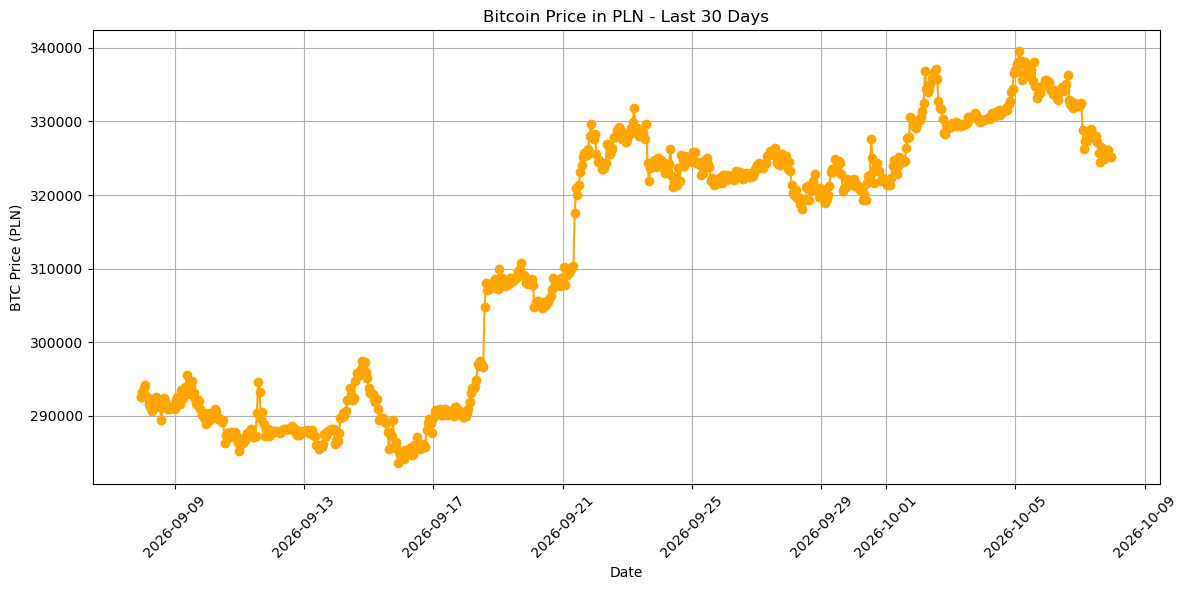

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# --------- ENSURE TIMESTAMP IS DATETIME ---------
df_crypto['timestamp'] = pd.to_datetime(df_crypto['timestamp'])
df_crypto.sort_values('timestamp', inplace=True)

# --------- PLOT LINE CHART ---------
plt.figure(figsize=(12, 6))
plt.plot(df_crypto['timestamp'], df_crypto['btc_pln'], marker='o', linestyle='-', color='orange')
plt.title("Bitcoin Price in PLN - Last 30 Days")
plt.xlabel("Date")
plt.ylabel("BTC Price (PLN)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
import requests
import pandas as pd

# --------- CONFIGURATION ---------
api_key = ""  # Replace with your CoinGecko API key if required (not always needed for public endpoints)

# --------- FETCH DAILY HISTORICAL DATA ---------
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {
    "vs_currency": "pln",
    "days": "30",         # last 30 days
    "interval": "daily"   # daily prices
}
headers = {"x-cg-demo-api-key": api_key}

response = requests.get(url, params=params, headers=headers)
data = response.json()

# --------- PROCESS DATA ---------
prices = data["prices"]  # list of [timestamp_ms, price]
df = pd.DataFrame(prices, columns=["timestamp_ms", "btc_pln"])
df["date"] = pd.to_datetime(df["timestamp_ms"], unit='ms').dt.date
df = df[["date", "btc_pln"]]



In [28]:
df.to_csv("bitcoin_price_daily.csv", index=False)

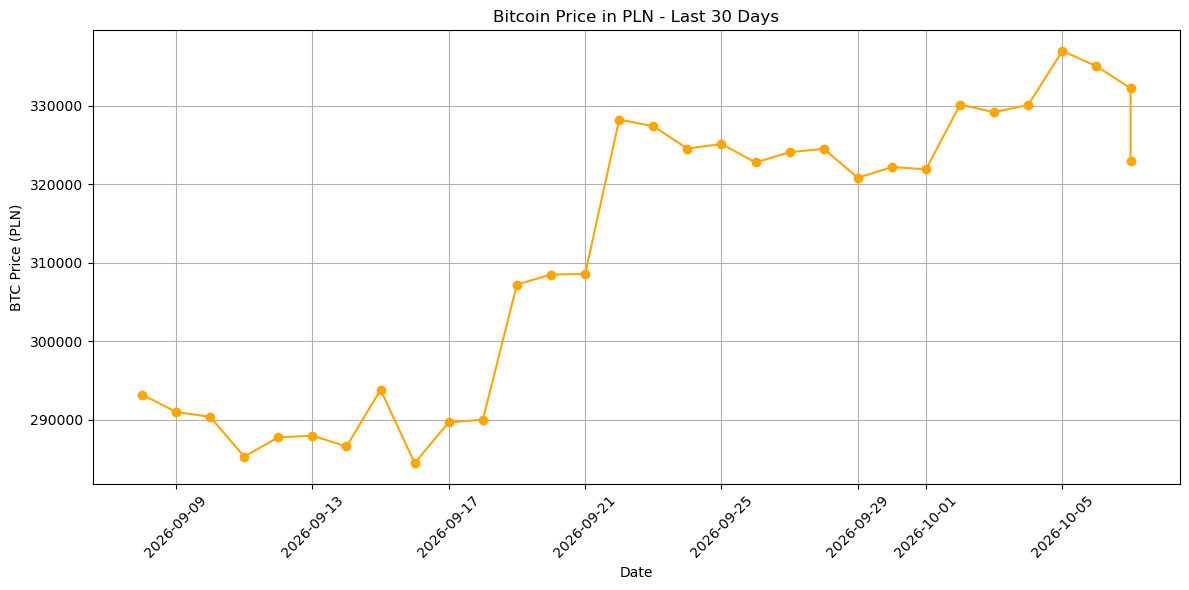

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# --------- LOAD CSV ---------
df_crypto = pd.read_csv("bitcoin_price_daily.csv")

# Ensure the 'date' column is recognized as datetime
df_crypto['date'] = pd.to_datetime(df_crypto['date'])

# --------- PLOT LINE CHART ---------
plt.figure(figsize=(12, 6))
plt.plot(df_crypto['date'], df_crypto['btc_pln'], marker='o', linestyle='-', color='orange')
plt.title("Bitcoin Price in PLN - Last 30 Days")
plt.xlabel("Date")
plt.ylabel("BTC Price (PLN)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
